# 1: Data Engineering & EDA - Transform "noisy" raw data into a clean, feature-rich dataset

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# Create or reuse a Spark session.
# local[*] uses all available local CPU cores and follows the same local Spark style used in the labs.
spark = (
    SparkSession.builder
    .appName("TractorFailurePrediction_Section_1_1")
    .master("local[*]")
    .getOrCreate()
)

sc = spark.sparkContext

print("Spark version:", sc.version)
print("Spark master:", sc.master)
print("Default parallelism:", sc.defaultParallelism)

Spark version: 4.1.1
Spark master: local[*]
Default parallelism: 12


## Quality Control and Cleaning

In [2]:
telemetry_path = "work/data/telemetry_raw.csv"

telemetry_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(telemetry_path)
)

telemetry_raw = spark.createDataFrame(
    sc.parallelize(telemetry_df.collect(), 4),
    telemetry_df.schema
)

print("Raw telemetry partitions:",
      telemetry_raw.rdd.getNumPartitions())

telemetry_raw.show(5)

Raw telemetry partitions: 4
+----------+---+---------------+----------+------------+-----------------+
|tractor_id|day|vibration_index|heat_index|oil_pressure|sensor_error_code|
+----------+---+---------------+----------+------------+-----------------+
|     T-000|  1|           7.15|     63.54|       64.12|                0|
|     T-000|  2|           6.49|     65.25|       53.24|                0|
|     T-000|  3|           7.55|     71.94|       39.91|                1|
|     T-000|  4|           8.86|      59.4|       57.34|                0|
|     T-000|  5|           8.21|     67.06|       66.98|                0|
+----------+---+---------------+----------+------------+-----------------+
only showing top 5 rows


In [3]:
print(telemetry_raw.rdd.toDebugString().decode("utf-8"))

(4) MapPartitionsRDD[21] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  MapPartitionsRDD[20] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  SQLExecutionRDD[19] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  MapPartitionsRDD[18] at javaToPython at NativeMethodAccessorImpl.java:0 []
 |  MapPartitionsRDD[17] at applySchemaToPythonRDD at NativeMethodAccessorImpl.java:0 []
 |  MapPartitionsRDD[16] at map at SerDeUtil.scala:71 []
 |  MapPartitionsRDD[15] at mapPartitions at SerDeUtil.scala:119 []
 |  PythonRDD[14] at RDD at PythonRDD.scala:58 []
 |  ParallelCollectionRDD[13] at readRDDFromFile at PythonRDD.scala:299 []


### Inspect the schema

In [4]:
telemetry_raw.printSchema()

root
 |-- tractor_id: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- vibration_index: double (nullable = true)
 |-- heat_index: double (nullable = true)
 |-- oil_pressure: double (nullable = true)
 |-- sensor_error_code: integer (nullable = true)



In [5]:
telemetry_raw.columns

['tractor_id',
 'day',
 'vibration_index',
 'heat_index',
 'oil_pressure',
 'sensor_error_code']

In [6]:
raw_row_count = telemetry_raw.count()

print(f"Total number of raw telemetry records: {raw_row_count}")

Total number of raw telemetry records: 7500


### Filter corrupted sensor records

In [7]:
telemetry_clean = telemetry_raw.filter(col("sensor_error_code") == 0)

telemetry_clean.show(5)

+----------+---+---------------+----------+------------+-----------------+
|tractor_id|day|vibration_index|heat_index|oil_pressure|sensor_error_code|
+----------+---+---------------+----------+------------+-----------------+
|     T-000|  1|           7.15|     63.54|       64.12|                0|
|     T-000|  2|           6.49|     65.25|       53.24|                0|
|     T-000|  4|           8.86|      59.4|       57.34|                0|
|     T-000|  5|           8.21|     67.06|       66.98|                0|
|     T-000|  6|           6.75|     60.16|       58.26|                0|
+----------+---+---------------+----------+------------+-----------------+
only showing top 5 rows


In [8]:
print("Clean telemetry partitions:",
      telemetry_clean.rdd.getNumPartitions())

Clean telemetry partitions: 4


In [9]:
clean_row_count = telemetry_clean.count()

print(f"Number of clean telemetry records: {clean_row_count}")

Number of clean telemetry records: 7017


In [10]:
dropped_rows = raw_row_count - clean_row_count

corrupted_percentage = (dropped_rows / raw_row_count) * 100

print(f"Rows before cleaning: {raw_row_count}")
print(f"Rows after cleaning: {clean_row_count}")
print(f"Rows dropped: {dropped_rows}")
print(f"Corrupted data percentage: {corrupted_percentage:.2f}%")

Rows before cleaning: 7500
Rows after cleaning: 7017
Rows dropped: 483
Corrupted data percentage: 6.44%


### Advanced Feature Engineering

In [11]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, floor, avg, min, max, count, round
from pyspark.sql.functions import rand

telemetry_marked = telemetry_clean.withColumn(
    "window_id",
    floor((col("day") - 1) / 3) + 1
)

window_3day = (
    Window
    .partitionBy("tractor_id", "window_id")
)

telemetry_window_features = (
    telemetry_marked
    .withColumn(
        "start_day",
        min("day").over(window_3day)
    )
    .withColumn(
        "end_day",
        max("day").over(window_3day)
    )
    .withColumn(
        "records_in_window",
        count("*").over(window_3day)
    )
    .withColumn(
        "vibration_3day_avg",
        round(avg("vibration_index").over(window_3day), 2)
    )
    .withColumn(
        "heat_3day_avg",
        round(avg("heat_index").over(window_3day), 2)
    )
)

telemetry_3day_features = (
    telemetry_window_features
    .select(
        "tractor_id",
        "window_id",
        "start_day",
        "end_day",
        "records_in_window",
        "vibration_3day_avg",
        "heat_3day_avg"
    )
    .dropDuplicates(["tractor_id", "window_id"])
    .orderBy("tractor_id", "window_id")
)

telemetry_3day_features.orderBy(rand(seed=42)).show(10)

+----------+---------+---------+-------+-----------------+------------------+-------------+
|tractor_id|window_id|start_day|end_day|records_in_window|vibration_3day_avg|heat_3day_avg|
+----------+---------+---------+-------+-----------------+------------------+-------------+
|     T-182|        5|       13|     15|                3|             16.62|        85.08|
|     T-164|        4|       11|     12|                2|              8.38|         67.0|
|     T-209|       10|       28|     30|                3|              8.42|        66.41|
|     T-025|        6|       16|     18|                3|              10.1|        74.74|
|     T-140|        6|       16|     18|                3|             15.64|        92.28|
|     T-237|        8|       22|     24|                3|              7.61|        66.12|
|     T-169|        2|        4|      6|                3|              8.78|        67.17|
|     T-120|        9|       25|     27|                3|              9.84|   

## Data Integration

In [12]:
maintenance_path = "work/data/maintenance_registry.csv"

maintenance_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(maintenance_path)
)

maintenance_registry = spark.createDataFrame(
    sc.parallelize(maintenance_df.collect(), 4),
    maintenance_df.schema
)

print("Maintenance registry partitions:",
      maintenance_registry.rdd.getNumPartitions())

maintenance_registry.show(5)

Maintenance registry partitions: 4
+----------+---------+--------------+
|tractor_id|crop_type|failure_target|
+----------+---------+--------------+
|     T-000|     Corn|             0|
|     T-001| Soybeans|             1|
|     T-002|    Wheat|             1|
|     T-003|    Wheat|             0|
|     T-004|   Cotton|             0|
+----------+---------+--------------+
only showing top 5 rows


In [13]:
final_telemetry_table = (
    telemetry_clean
    .join(
        maintenance_registry,
        on="tractor_id",
        how="inner"
    )
)

print("Final telemetry table partitions:",
      final_telemetry_table.rdd.getNumPartitions())

final_telemetry_table.show(10)

Final telemetry table partitions: 1
+----------+---+---------------+----------+------------+-----------------+---------+--------------+
|tractor_id|day|vibration_index|heat_index|oil_pressure|sensor_error_code|crop_type|failure_target|
+----------+---+---------------+----------+------------+-----------------+---------+--------------+
|     T-052|  1|          10.22|     98.43|       62.64|                0|    Wheat|             1|
|     T-052|  2|          14.21|     79.37|        40.3|                0|    Wheat|             1|
|     T-052|  3|          17.16|     79.41|       67.28|                0|    Wheat|             1|
|     T-052|  4|          18.92|     94.16|       35.11|                0|    Wheat|             1|
|     T-052|  5|          13.77|     86.17|       45.97|                0|    Wheat|             1|
|     T-052|  6|          11.63|     91.32|       54.49|                0|    Wheat|             1|
|     T-052|  7|          17.08|     80.64|       37.16|        

In [14]:
output_path = "work/data/final_telemetry_table.parquet"

final_telemetry_table.write.mode("overwrite").parquet(output_path)

print("Final table saved as Parquet:", output_path)

Final table saved as Parquet: work/data/final_telemetry_table.parquet


## Visual Exploration

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
parquet_path = "work/data/final_telemetry_table.parquet"

final_telemetry_from_parquet = spark.read.parquet(parquet_path)

final_telemetry_from_parquet.show(10)

+----------+---+---------------+----------+------------+-----------------+---------+--------------+
|tractor_id|day|vibration_index|heat_index|oil_pressure|sensor_error_code|crop_type|failure_target|
+----------+---+---------------+----------+------------+-----------------+---------+--------------+
|     T-052| 30|          13.71|      88.5|       41.05|                0|    Wheat|             1|
|     T-052| 29|          11.81|     97.33|       56.33|                0|    Wheat|             1|
|     T-052| 28|          10.66|     90.84|       31.05|                0|    Wheat|             1|
|     T-052| 27|          15.92|     85.53|       58.16|                0|    Wheat|             1|
|     T-052| 26|          17.92|     76.78|       49.83|                0|    Wheat|             1|
|     T-052| 25|          13.77|     77.42|       58.35|                0|    Wheat|             1|
|     T-052| 24|          10.95|     91.14|       60.28|                0|    Wheat|             1|


In [17]:
images_dir = "work/images"
os.makedirs(images_dir, exist_ok=True)

In [18]:
visual_sample = (
    final_telemetry_from_parquet
    .select(
        "tractor_id",
        "heat_index",
        "failure_target"
    )
    .sample(
        withReplacement=False,
        fraction=0.3,
        seed=42
    )
)

visual_sample.show(10)

+----------+----------+--------------+
|tractor_id|heat_index|failure_target|
+----------+----------+--------------+
|     T-052|     85.53|             1|
|     T-052|     76.15|             1|
|     T-052|      84.9|             1|
|     T-052|     87.32|             1|
|     T-052|     79.41|             1|
|     T-052|     79.37|             1|
|     T-031|     67.97|             0|
|     T-031|     70.07|             0|
|     T-031|     58.99|             0|
|     T-031|     61.14|             0|
+----------+----------+--------------+
only showing top 10 rows


In [19]:
visual_pd = visual_sample.toPandas()

visual_pd["failure_label"] = visual_pd["failure_target"].map({
    0: "Healthy",
    1: "Failing"
})

visual_pd.head()

,tractor_id,heat_index,failure_target,failure_label
0,T-052,85.53,1,Failing
1,T-052,76.15,1,Failing
2,T-052,84.90,1,Failing
3,T-052,87.32,1,Failing
4,T-052,79.41,1,Failing


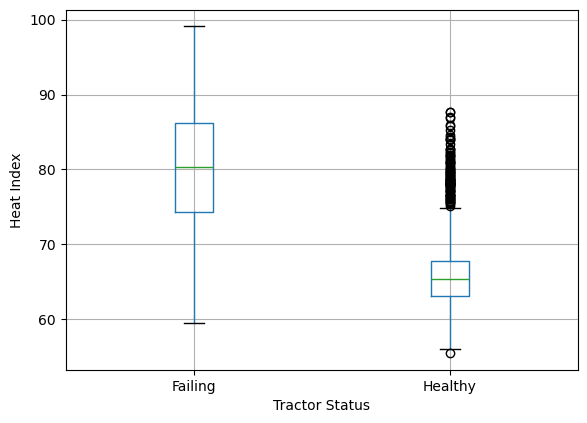

In [20]:
ax = visual_pd.boxplot(
    column="heat_index",
    by="failure_label"
)

ax.set_title("")
plt.suptitle("")

plt.xlabel("Tractor Status")
plt.ylabel("Heat Index")

plt.savefig(
    "work/images/heat_index_failure_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Section 2: Machine Learning & Modeling (Build a predictive model at scale using Spark MLlib)

## Create a Spark ML Pipeline

In [21]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

In [22]:
final_data_path = "work/data/final_telemetry_table.parquet"

ml_data = spark.read.parquet(final_data_path)
print("ML data count:", ml_data.count())
ml_data.show(5)

ML data count: 7017
+----------+---+---------------+----------+------------+-----------------+---------+--------------+
|tractor_id|day|vibration_index|heat_index|oil_pressure|sensor_error_code|crop_type|failure_target|
+----------+---+---------------+----------+------------+-----------------+---------+--------------+
|     T-052| 30|          13.71|      88.5|       41.05|                0|    Wheat|             1|
|     T-052| 29|          11.81|     97.33|       56.33|                0|    Wheat|             1|
|     T-052| 28|          10.66|     90.84|       31.05|                0|    Wheat|             1|
|     T-052| 27|          15.92|     85.53|       58.16|                0|    Wheat|             1|
|     T-052| 26|          17.92|     76.78|       49.83|                0|    Wheat|             1|
+----------+---+---------------+----------+------------+-----------------+---------+--------------+
only showing top 5 rows


In [23]:
crop_indexer = StringIndexer(
    inputCol="crop_type",
    outputCol="crop_type_index",
    handleInvalid="keep"
)

In [24]:
feature_columns = [
    "vibration_index",
    "heat_index",
    "oil_pressure"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="raw_features"
)

In [25]:
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=False,
    withStd=True
)

In [26]:
ml_pipeline = Pipeline(
    stages=[
        crop_indexer,
        assembler,
        scaler
    ]
)

## Training & Cross-Validation

In [27]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

In [28]:
train_data, test_data = ml_data.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_data.count())
print("Testing records:", test_data.count())

Training records: 5677
Testing records: 1340


In [29]:
rf = RandomForestClassifier(
    labelCol="failure_target",
    featuresCol="features",
    seed=42
)

In [30]:
full_pipeline = Pipeline(
    stages=[
        crop_indexer,
        assembler,
        scaler,
        rf
    ]
)

In [31]:
param_grid = (
    ParamGridBuilder()
    .addGrid(rf.maxDepth, [5, 10, 15])
    .build()
)

In [32]:
evaluator = BinaryClassificationEvaluator(
    labelCol="failure_target",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [33]:
cross_validator = CrossValidator(
    estimator=full_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=evaluator,
    numFolds=3,
    seed=42
)

In [34]:
cv_model = cross_validator.fit(train_data)

## Model Evaluation

In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

images_dir = "work/images"
os.makedirs(images_dir, exist_ok=True)

In [36]:
predictions = cv_model.transform(test_data)

predictions.select(
    "tractor_id",
    "crop_type",
    "vibration_index",
    "heat_index",
    "oil_pressure",
    "failure_target",
    "prediction",
    "probability"
).show(10, truncate=False)

+----------+---------+---------------+----------+------------+--------------+----------+-----------------------------------------+
|tractor_id|crop_type|vibration_index|heat_index|oil_pressure|failure_target|prediction|probability                              |
+----------+---------+---------------+----------+------------+--------------+----------+-----------------------------------------+
|T-000     |Corn     |8.86           |59.4      |57.34       |0             |0.0       |[0.9931851261871655,0.006814873812834436]|
|T-000     |Corn     |8.39           |68.27     |46.13       |0             |0.0       |[0.9931851261871655,0.006814873812834436]|
|T-000     |Corn     |6.86           |67.04     |56.2        |0             |0.0       |[0.9931851261871655,0.006814873812834436]|
|T-000     |Corn     |6.62           |71.43     |47.98       |0             |0.0       |[0.9647829737050578,0.03521702629494214] |
|T-000     |Corn     |8.57           |62.62     |61.53       |0             |0.0   

In [37]:
confusion_matrix = (
    predictions
    .groupBy("failure_target", "prediction")
    .count()
    .orderBy("failure_target", "prediction")
)

confusion_matrix.show()

+--------------+----------+-----+
|failure_target|prediction|count|
+--------------+----------+-----+
|             0|       0.0|  951|
|             0|       1.0|  106|
|             1|       0.0|   17|
|             1|       1.0|  266|
+--------------+----------+-----+



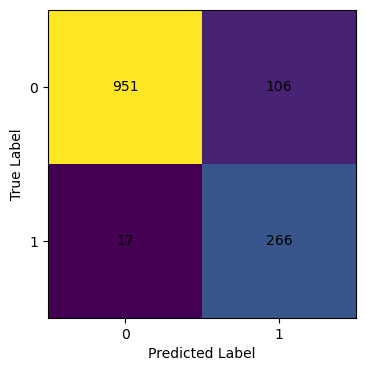

In [38]:
confusion_pd = confusion_matrix.toPandas()

confusion_pivot = confusion_pd.pivot(
    index="failure_target",
    columns="prediction",
    values="count"
).fillna(0)

plt.figure(figsize=(5, 4))
plt.imshow(confusion_pivot.values)

plt.xticks(
    range(len(confusion_pivot.columns)),
    [str(int(x)) for x in confusion_pivot.columns]
)
plt.yticks(
    range(len(confusion_pivot.index)),
    [str(int(x)) for x in confusion_pivot.index]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
# plt.title("Confusion Matrix")

for i in range(confusion_pivot.shape[0]):
    for j in range(confusion_pivot.shape[1]):
        plt.text(
            j,
            i,
            int(confusion_pivot.values[i, j]),
            ha="center",
            va="center"
        )

plt.savefig(
    "work/images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
auc = evaluator.evaluate(predictions)

print(f"Area Under ROC Curve AUC: {auc:.4f}")

Area Under ROC Curve AUC: 0.9585


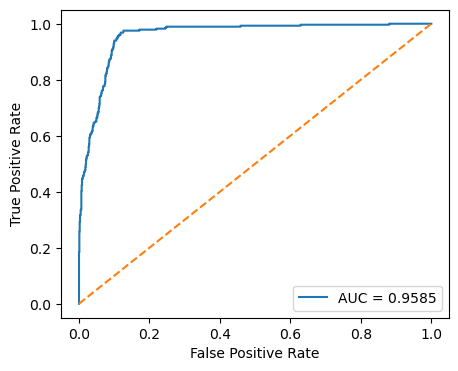

In [40]:
roc_data = (
    predictions
    .select(
        "failure_target",
        vector_to_array("probability")[1].alias("failure_probability")
    )
    .toPandas()
)

roc_data = roc_data.sort_values(
    by="failure_probability",
    ascending=False
)

total_positive = (roc_data["failure_target"] == 1).sum()
total_negative = (roc_data["failure_target"] == 0).sum()

true_positives = 0
false_positives = 0

tpr_values = [0.0]
fpr_values = [0.0]

for _, row in roc_data.iterrows():
    if row["failure_target"] == 1:
        true_positives += 1
    else:
        false_positives += 1

    tpr_values.append(true_positives / total_positive)
    fpr_values.append(false_positives / total_negative)

plt.figure(figsize=(5, 4))
plt.plot(fpr_values, tpr_values, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# plt.title("ROC Curve")
plt.legend()

plt.savefig(
    "work/images/roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
best_pipeline_model = cv_model.bestModel
best_rf_model = best_pipeline_model.stages[-1]

print("Best Random Forest maxDepth:",
      best_rf_model.getMaxDepth())

feature_importances = best_rf_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "sensor": feature_columns,
    "importance": feature_importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_spark_df = spark.createDataFrame(importance_df)

importance_spark_df.show(truncate=False)

Best Random Forest maxDepth: 5
+---------------+---------------------+
|sensor         |importance           |
+---------------+---------------------+
|heat_index     |0.5930426685123015   |
|vibration_index|0.40032243940044926  |
|oil_pressure   |0.0066348920872492155|
+---------------+---------------------+



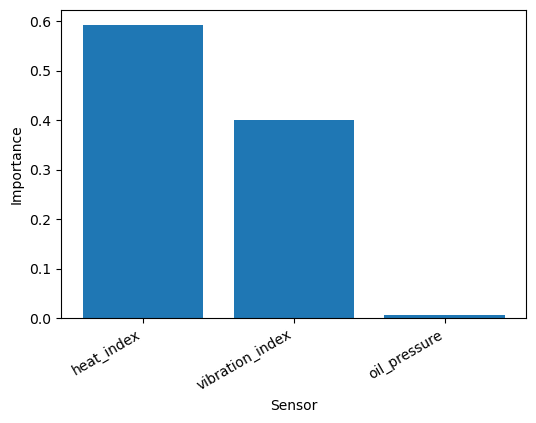

In [42]:
plt.figure(figsize=(6, 4))

plt.bar(
    importance_df["sensor"],
    importance_df["importance"]
)

plt.xlabel("Sensor")
plt.ylabel("Importance")
# plt.title("Random Forest Feature Importance")
plt.xticks(rotation=30, ha="right")

plt.savefig(
    "work/images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()